# Analyze imgep dataset
## Explain what are bus and ddr bandwidths

## Load datasets

In [1]:
import pickle
import numpy  as np
from exploration.load_file import load
from diversity.diversty import Diversity
import matplotlib.pyplot as plt

In [2]:
#Load data
folder = "results"
N = 100000
k=1
print_freq = 1000
name_imgep = f'{folder}/imgep_bandwidth_N_{N}_k_{k}'
name_random = f'{folder}/random_bandwidth_expl_N_{N}'
content_imgep = load(name_imgep)
content_imgep_tab = content_imgep['numpy_view']
content_random = load(name_random)
content_random_tab = content_random['numpy_view']
dim_out = 18
#Compute diversity
##################################
min_tab = np.zeros((dim_out,))
max_tab = np.ones((dim_out,))*10



results/imgep_bandwidth_N_100000_k_1_1.pkl
results/random_bandwidth_expl_N_100000_2.pkl


In [3]:
diversity_imgep_list = [100* Diversity(min_tab = min_tab,max_tab = max_tab,num_bins = num_bins)(content_imgep_tab[:])/(num_bins**dim_out) for num_bins in range(2,10)]
diversity_random_list = [100*Diversity(min_tab = min_tab,max_tab = max_tab,num_bins = num_bins)(content_random_tab[:])/(num_bins**dim_out) for num_bins in range(2,10)]

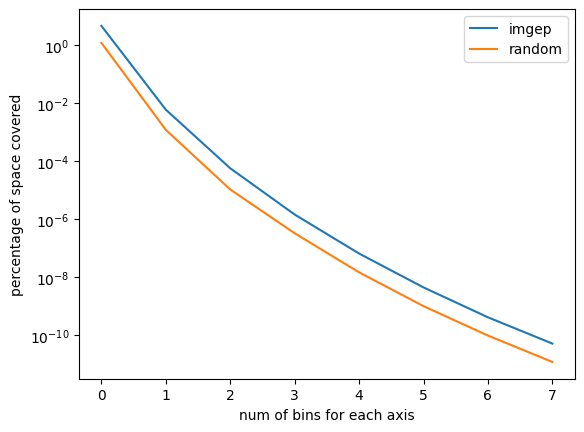

In [4]:
plt.semilogy(diversity_imgep_list,label='imgep')
plt.semilogy(diversity_random_list,label='random')
plt.ylabel('percentage of space covered')
plt.xlabel('num of bins for each axis')
plt.legend()

In [5]:
step = 1000
diversity_imgep_list = [100* Diversity(min_tab = min_tab,max_tab = max_tab,num_bins = 10)(content_imgep_tab[:step]) for step in range(step,N+1,step)]
diversity_random_list = [100*Diversity(min_tab = min_tab,max_tab = max_tab,num_bins = 10)(content_random_tab[:step]) for step in range(step,N+1,step)]

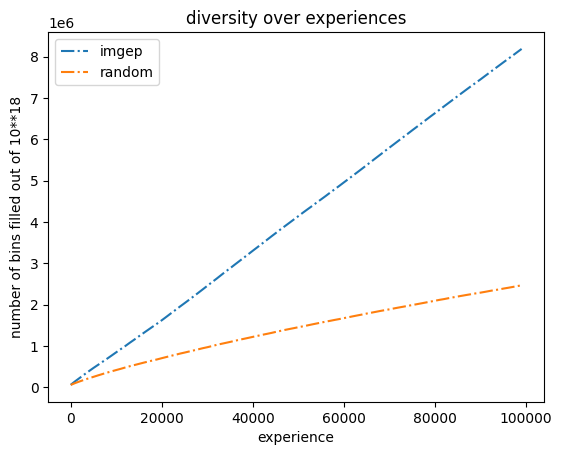

In [6]:
#print(f'diversity imgep {diversity_(content_imgep_tab)}/10**{dim_out}')
#print(f'diversity random {diversity_(content_random_tab)}/10**{dim_out}')
plt.figure()
plt.plot(range(0,N,print_freq),diversity_imgep_list,'-.',label="imgep")
plt.plot(range(0,N,print_freq),diversity_random_list,'-.',label="random")
plt.legend()
plt.title('diversity over experiences')
plt.xlabel('experience')
plt.ylabel(f'number of bins filled out of 10**{dim_out}')
plt.show()

In [7]:
combinaisons = lambda dimension: [(i,j) for j in range(1,dimension) for i in range(j)] 

In [8]:
content_imgep['memory_observation'].keys()

dict_keys(['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff', 'bus_bandwidth_core_0_iso', 'bus_bandwidth_core_0_core1', 'ddr_bandwidth_core_0_iso', 'ddr_bandwidth_core_0_core1', 'time_core0_iso', 'time_core0_core1'])

### Imgep finds more various points than random. However, no cluster seems to appear. For each time window, we focus on a 3D dimensional space, as we select variables that are different between isolation and parallel execution.
### Although no cluster is naturally appearing, one will employ (SVD,HDBSAN), (UMAP,HDBSCAN) and Kmeans to support this claim.

### One will color the following plots with the obtain clusters for constructive comparison between the methods

### Should I run imgep with much more time windows to see w

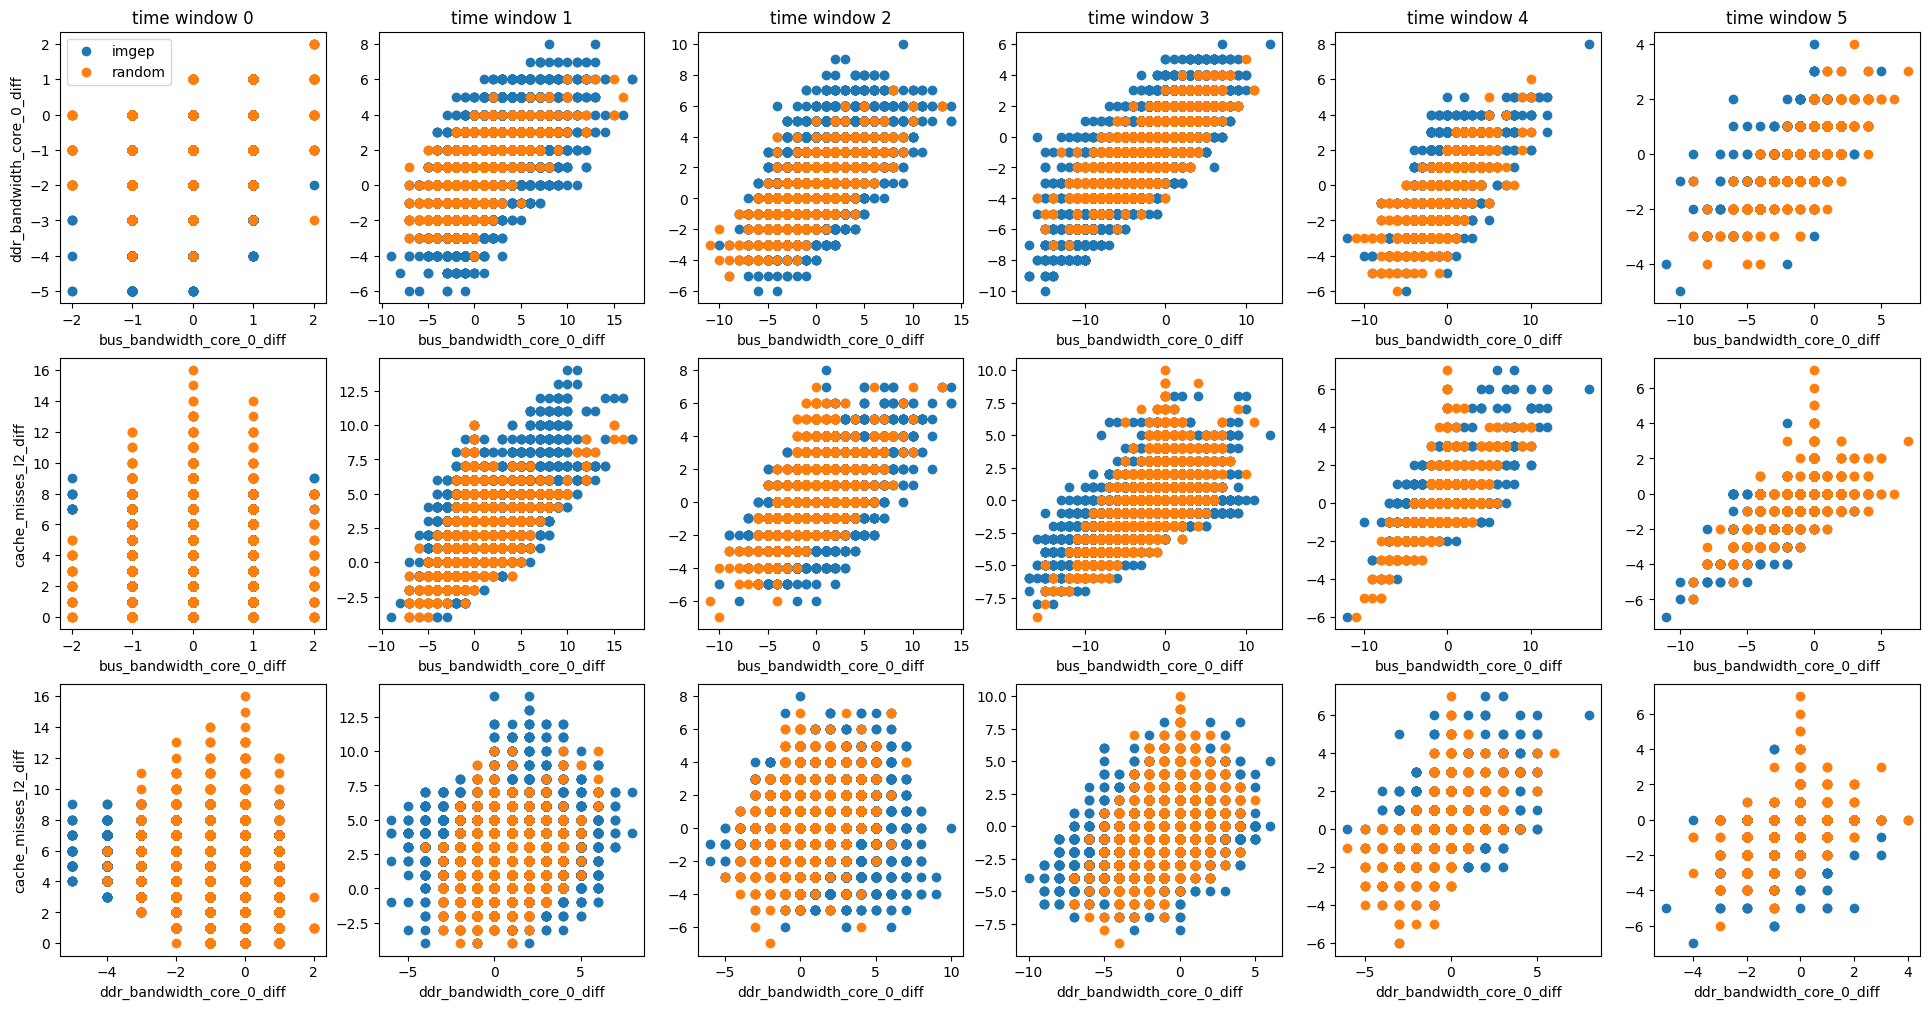

In [9]:
combins = combinaisons(3)
fig,axs = plt.subplots(len(combins),6,figsize=(24,12))
list_feature = ['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff']
for paire,(i,j) in enumerate(combins):
    for time in range(0,6):
        axs[paire,time].scatter(np.array(content_imgep['memory_observation'][list_feature[i]])[:,time],np.array(content_imgep['memory_observation'][list_feature[j]])[:,time],label='imgep')
        axs[paire,time].scatter(np.array(content_random['memory_observation'][list_feature[i]])[:,time],np.array(content_random['memory_observation'][list_feature[j]])[:,time],label='random')
        axs[paire,time].set_xlabel(list_feature[i])
        if paire==0:
            axs[0,time].set_title(f'time window {time}')
    axs[paire,0].set_ylabel(list_feature[j])
axs[0,0].legend()

# Attempt to identify clusters with SVD
**Remarks**

* Projection with inferior dimension do not allow to discriminate consistent poles


In [30]:
import umap
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import StandardScaler

In [11]:
feature_list = ['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff']
print(len(feature_list))

3


In [12]:
content_imgep['memory_observation']
content_array_time  = np.array([[[content_imgep['memory_observation'][feature][n][t] for feature in feature_list] for t in range(6)] for n in range(N)])

### Assuming there is a latent representation of each time stamp, we consider multiple and seperated populations for each time t, we consider a populations where outputs of experiments are considered as individuals.

In [15]:
norm = lambda data: (data - data.mean(axis=0))/data.std(axis=0)

(100000, 3)
[390.89193035 316.3091105  217.14521732]
(100000, 3)
[407.16444827 324.9983305  169.09523126]
(100000, 3)
[424.84492758 312.62298045 147.55900382]
(100000, 3)
[470.64915779 251.31752822 123.80981494]
(100000, 3)
[427.42593386 299.1904373  166.70978762]
(100000, 3)
[444.56765457 301.34009705 107.48835482]


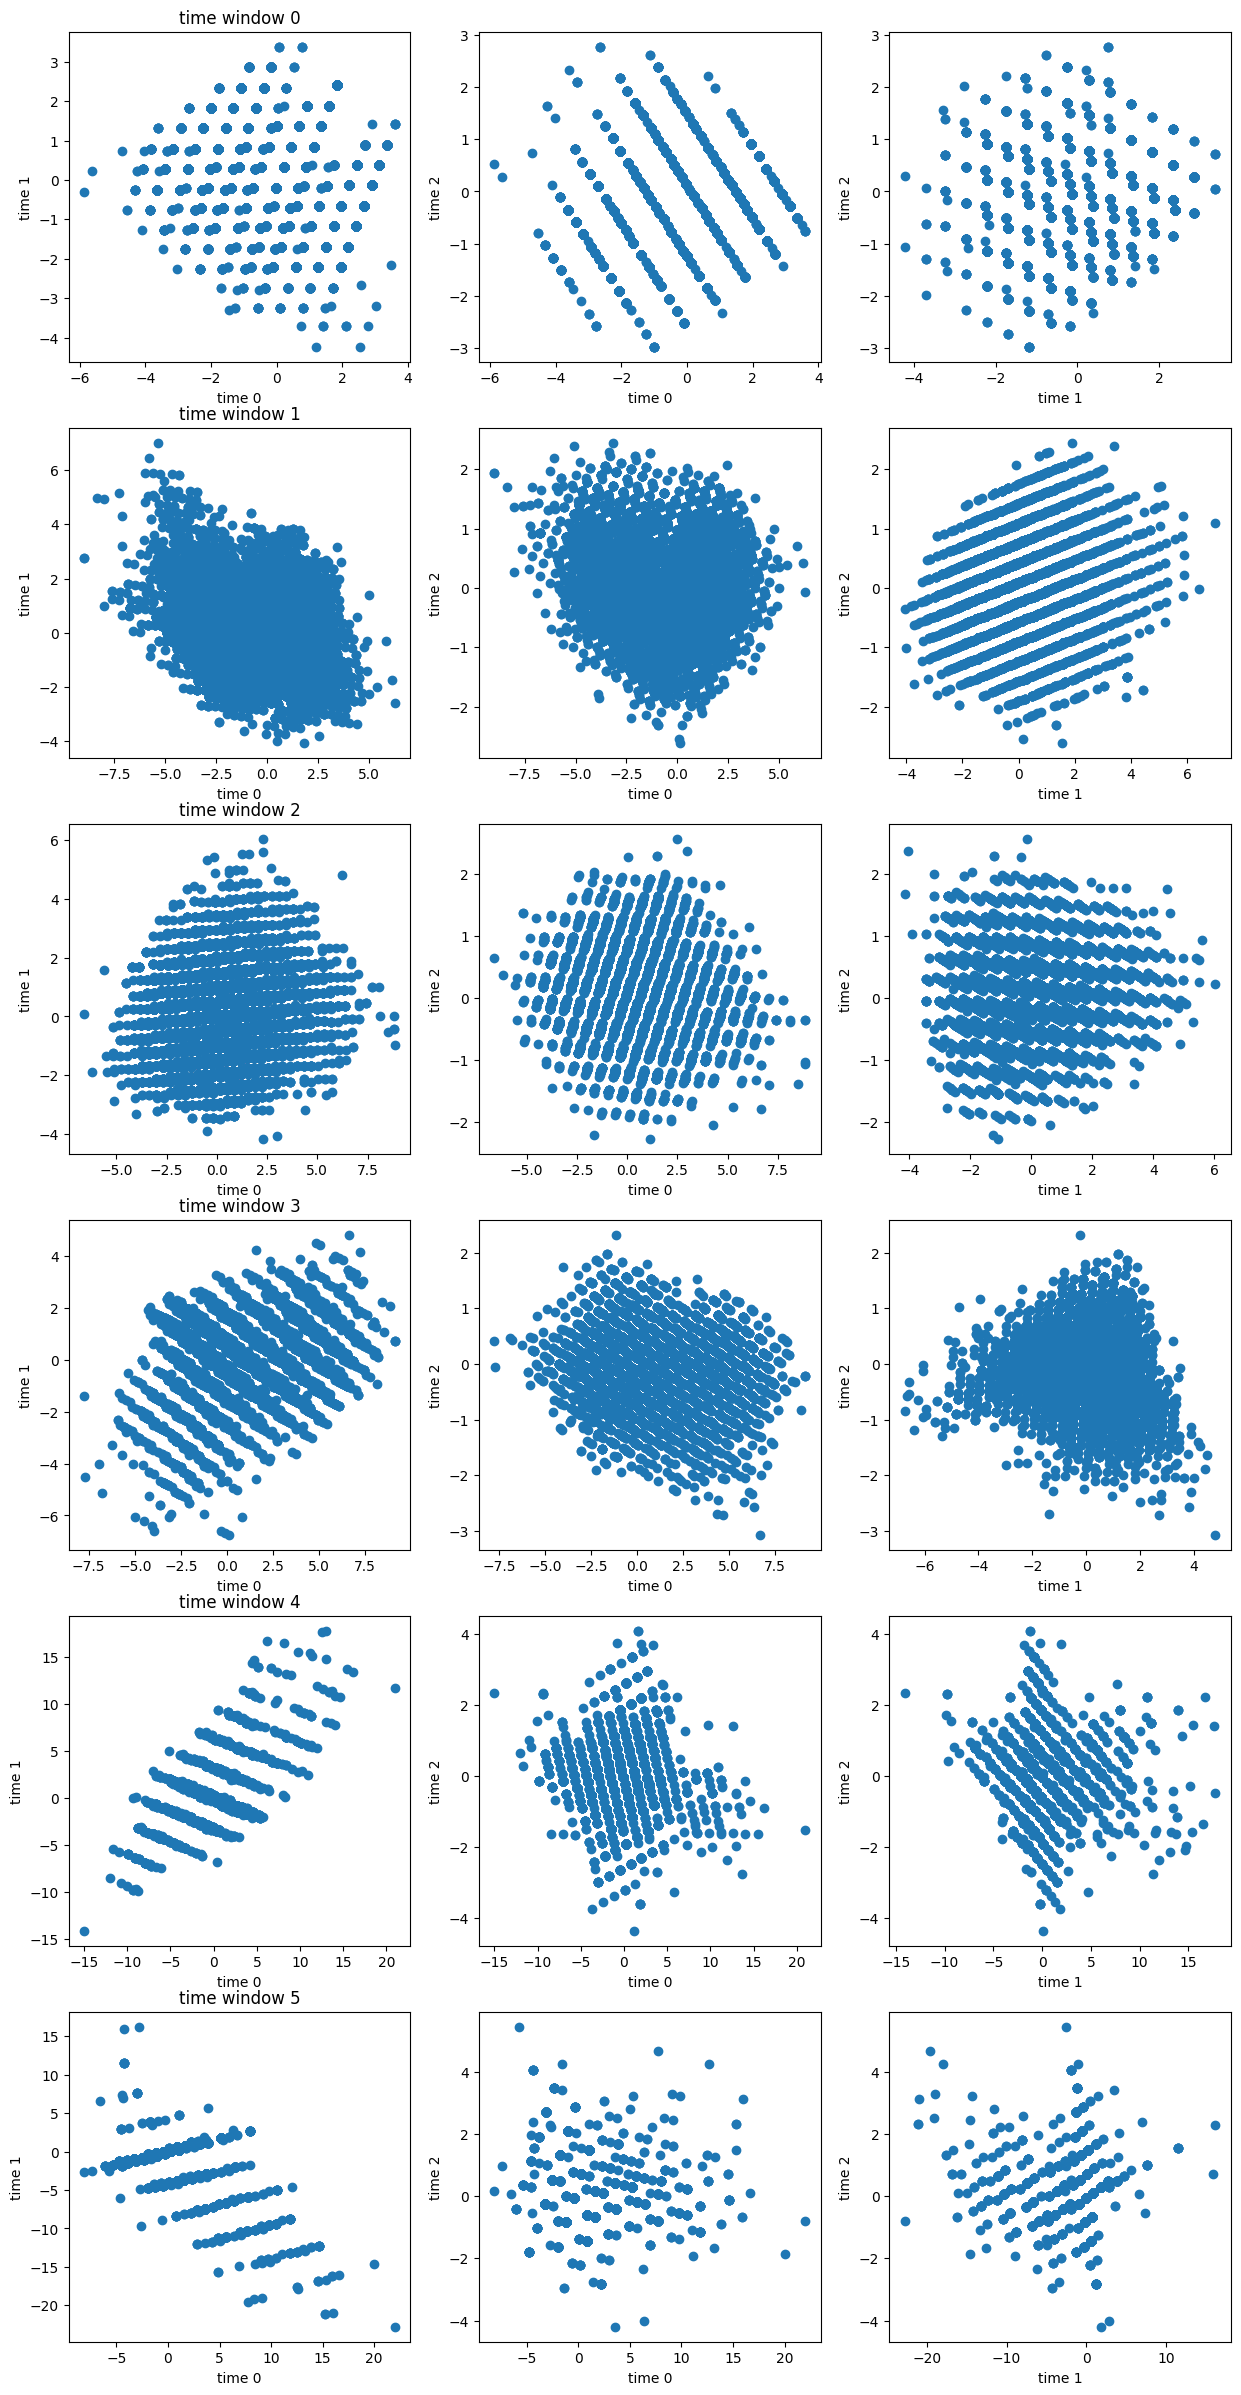

In [28]:

coords = combinaisons(3)
fig,axs = plt.subplots(6,len(coords),figsize=(15,30))
for t in range(6):
    X = content_array_time[:,t,:]
    X = norm(X)
    U,Sig,Vt = np.linalg.svd(X,full_matrices=False)
    proj = U*Sig
    print(proj.shape)
    print(Sig)
    proj[0]
    for c,(i,j) in enumerate(coords[:]):
        axs[t,c].scatter(proj[:,i],proj[:,j])    
        axs[t,c].set_xlabel(f'time {i}')
        axs[t,c].set_ylabel(f'time {j}')
    axs[t,0].set_title(f'time window {t}')
    #axs[t,c].legend()
#fig.tight_layout()
plt.show()

In [43]:
hdb = HDBSCAN(copy=True, min_cluster_size=1000)
hdb.fit(proj[:,:])

,min_cluster_size,1000
,min_samples,None
,cluster_selection_epsilon,0.0
,max_cluster_size,None
,metric,'euclidean'
,metric_params,None
,alpha,1.0
,algorithm,'auto'
,leaf_size,40
,n_jobs,None
,cluster_selection_method,'eom'


In [44]:
data_list = {key:[] for key in np.unique(hdb.labels_)}   
for j in range(N):
    data_list[hdb.labels_[j]].append(proj[j])
for label in data_list:
    print(f'num elem label {label}: {len(data_list[label])}')
    data_list[label] = np.array(data_list[label])

num elem label -1: 1610
num elem label 0: 1024
num elem label 1: 1251
num elem label 2: 2204
num elem label 3: 2161
num elem label 4: 1313
num elem label 5: 12415
num elem label 6: 75898
num elem label 7: 2124


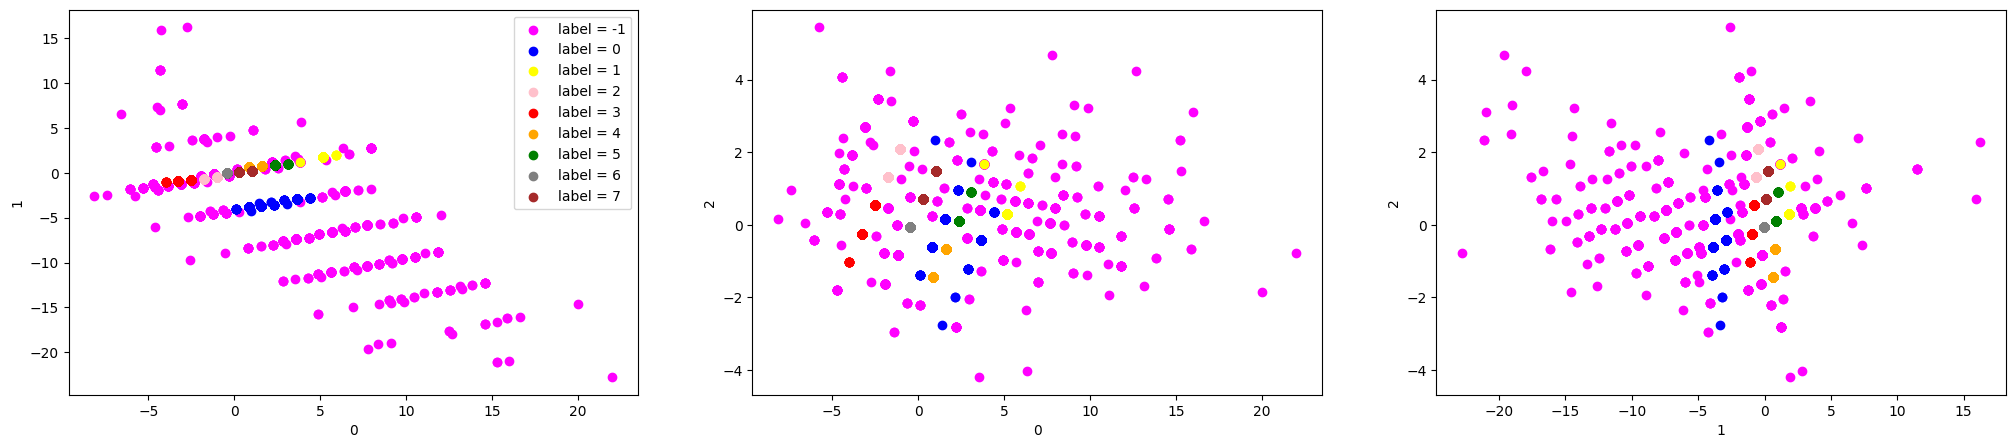

In [47]:
coords = combinaisons(3)
fig,axs = plt.subplots(1,len(coords),figsize=(25,5))
for clust in np.unique(hdb.labels_):
    if True:
        for c,(i,j) in enumerate(coords):
            axs[c].scatter(data_list[clust][:,i],data_list[clust][:,j],color = ['blue','yellow','pink','red','orange','green','gray','brown','purple','magenta'][clust],label=f'label = {clust}')   
            axs[c].set_xlabel(i)
            axs[c].set_ylabel(j)
axs[0].legend()

# Attempt to identify clusters with UMAP

# UMAP on matrix containing all data, each individual is contenation of flatten trajectories for each feature

In [ ]:
reducer = umap.UMAP(n_components=6,metric="euclidean")
embedding = reducer.fit_transform(data)

In [50]:
data = content_imgep['numpy_view']
print('data shape', data.shape)

data shape (100000, 18)


In [64]:
dimension = 5
idx = [(i,j) for j in range(1,dimension) for i in range(j)]
print(len(idx))

10


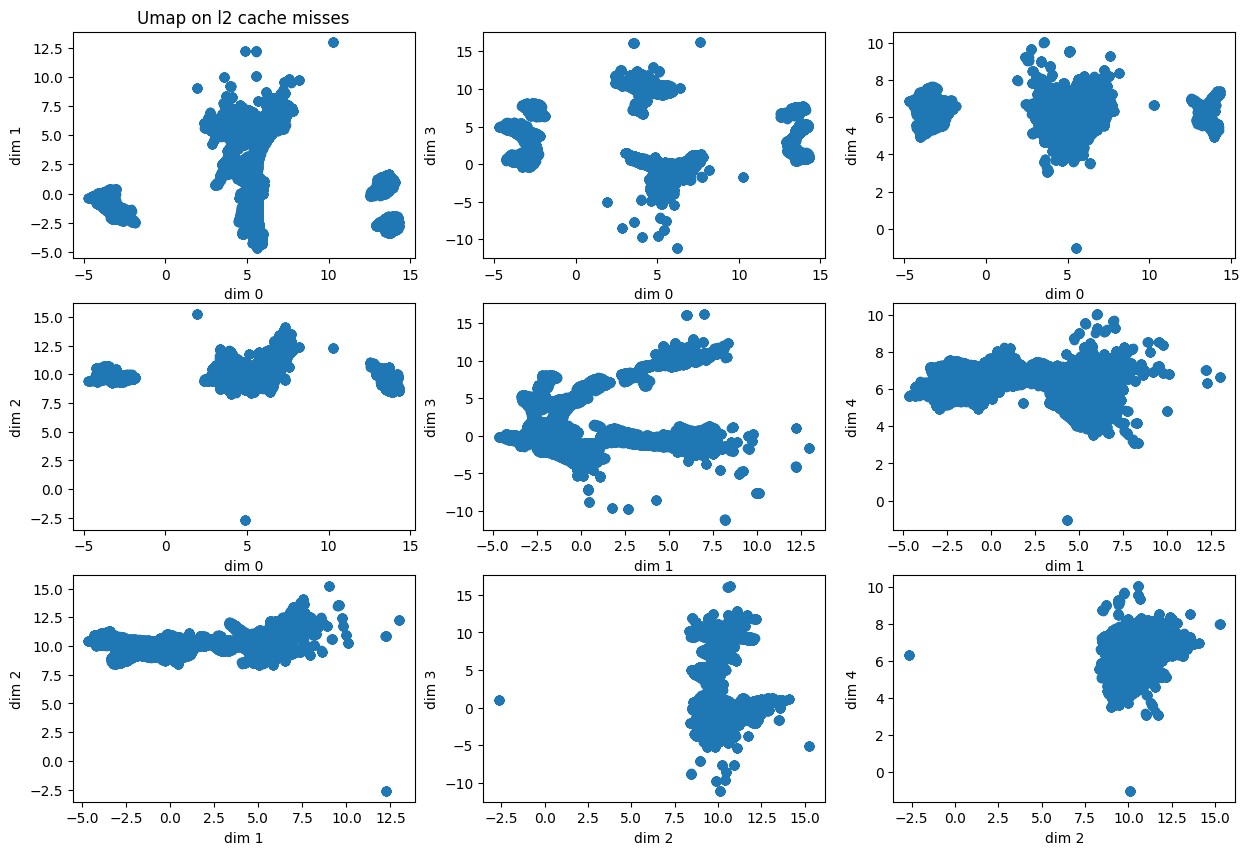

In [65]:
fig,axs=plt.subplots(3,3,figsize=(15,10))

for j in range(9):
    axs[j%3,j//3].scatter(embedding[:,idx[j][0]],embedding[:,idx[j][1]])
    axs[j%3,j//3].set_xlabel(f'dim {idx[j][0]}')
    axs[j%3,j//3].set_ylabel(f'dim {idx[j][1]}')
    if j==0:
        axs[j%2,j//2].set_title('Umap on l2 cache misses')
plt.show()

In [ ]:
hdb = HDBSCAN(copy=True, min_cluster_size=2000)
hdb.fit(embedding)
print('hdb labels:',hdb.labels_)
print('labels',np.unique(hdb.labels_))

In [ ]:
data_list = {key:[] for key in np.unique(hdb.labels_)}   
for j in range(N):
        data_list[hdb.labels_[j]].append(embedding[j])

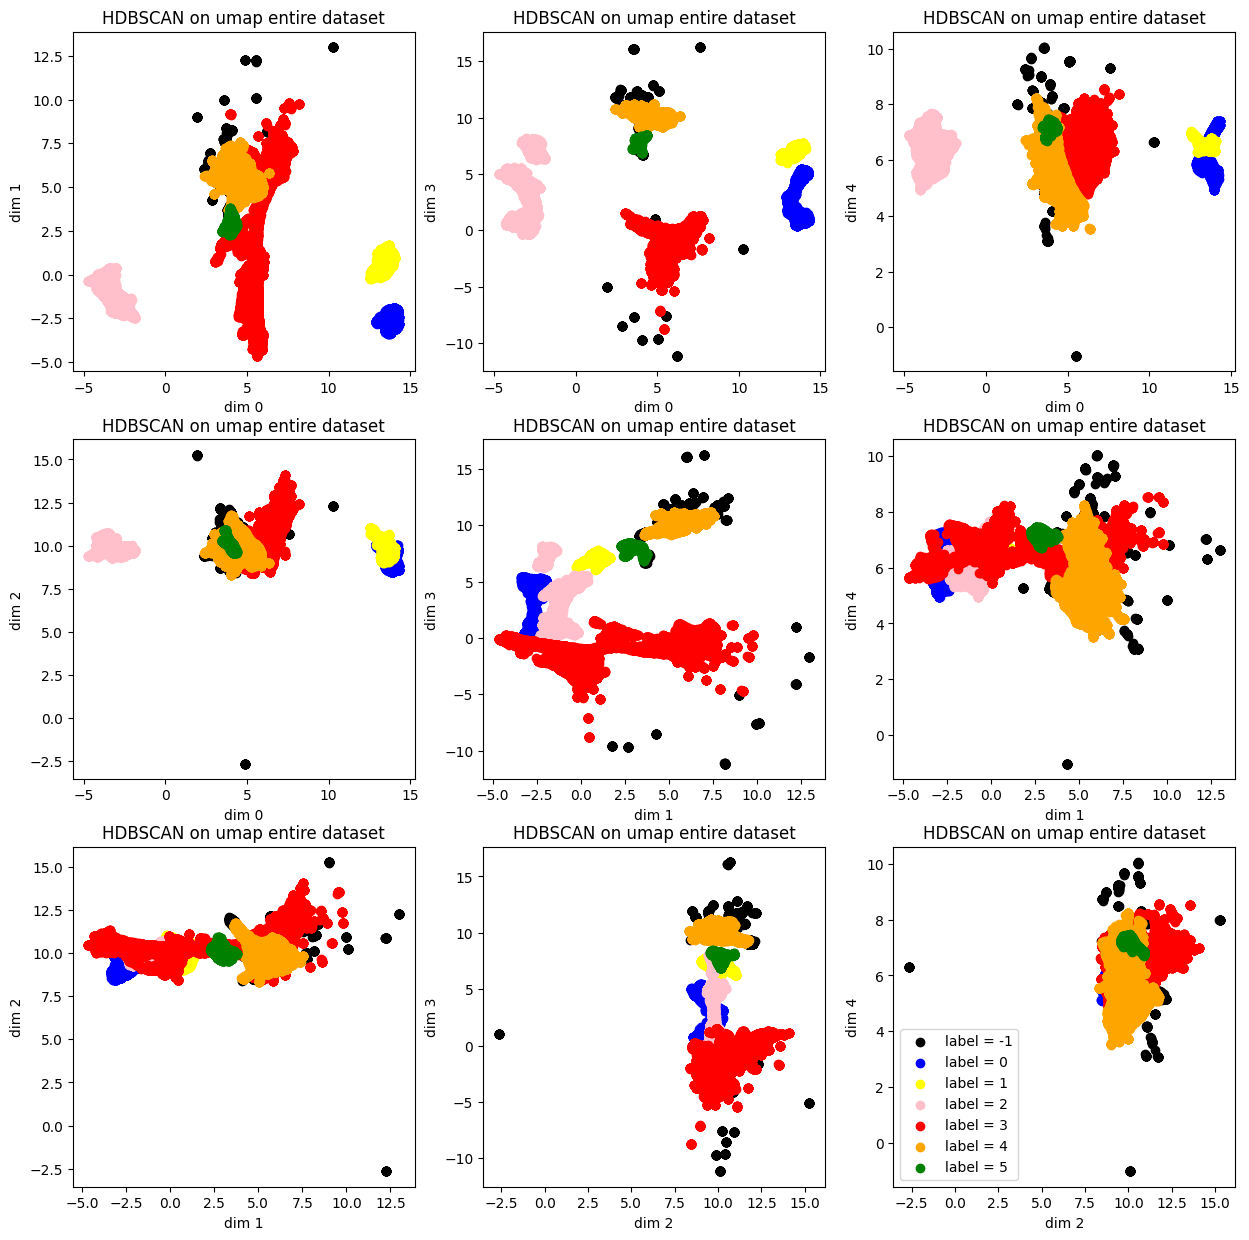

num elem label -1: 2027
num elem label 0: 10487
num elem label 1: 4597
num elem label 2: 15091
num elem label 3: 47282
num elem label 4: 17955
num elem label 5: 2561


In [66]:
fig,axs=plt.subplots(3,3,figsize=(15,15))
for i in range(9):
    for j,key in enumerate(data_list):
        axs[i%3,i//3].scatter(np.array(data_list[key])[:,idx[i][0]],np.array(data_list[key])[:,idx[i][1]],color = ['black','blue','yellow','pink','red','orange','green','gray','brown','purple','magenta'][j],label=f'label = {key}')
        axs[i%3,i//3].set_title('HDBSCAN on umap entire dataset')
        axs[i%3,i//3].set_xlabel(f'dim {idx[i][0]}')
        axs[i%3,i//3].set_ylabel(f'dim {idx[i][1]}')
plt.legend()
plt.show()
for label in data_list:
    print(f'num elem label {label}: {len(data_list[label])}')

In [68]:
clusters_imgep = {key:{feature:[] for feature in content_imgep['memory_observation'].keys()} for key in np.unique(hdb.labels_)}   
for j in range(N):
        for feature in content_imgep['memory_observation']:
            clusters_imgep[hdb.labels_[j]][feature].append(content_imgep['memory_observation'][feature][j])

cluster -1
(2027, 6)
mean [ 0.00542674  0.00641342 -0.02417366 -1.56536754  0.10902812 -0.49481993]
std [0.09141843 0.2560724  2.01790401 5.2494785  0.47477296 1.29792358]
cluster 0
(10487, 6)
mean [-1.00104892  2.03680748 -0.10803852 -1.13988748  0.30084867 -0.36931439]
std [0.03237001 2.18958831 1.93344472 2.65098626 1.27678968 0.91929744]
cluster 1
(4597, 6)
mean [-1.0006526   0.97193822  0.1390037  -0.23297803 -0.07461388 -0.33456602]
std [0.02553769 0.81124628 2.03109269 2.54288775 1.06881024 0.90528594]
cluster 2
(15091, 6)
mean [ 1.00092771 -0.28765489 -0.09084885 -0.49956928  0.11940892 -0.35577497]
std [0.03044412 1.97409319 1.81334348 2.70197933 1.18022788 0.90657061]
cluster 3
(47282, 6)
mean [ 1.26898185e-04  1.01474134e+00  1.12897086e-01 -1.04657163e+00
  1.74040861e-01 -3.34355569e-01]
std [0.03379449 2.27385077 1.99301557 2.79884623 1.33651728 0.9233696 ]
cluster 4
(17955, 6)
mean [ 0.0011139  -0.10938457  0.72252854  0.02818157 -0.21748816  0.03492063]
std [0.03803714 

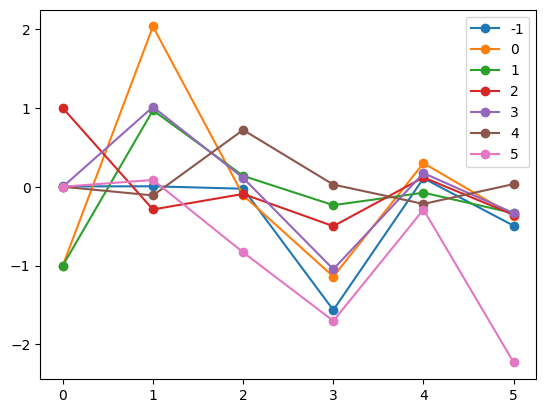

cluster -1
(2027, 6)
mean [-0.25012333  0.06265417  0.46176616 -1.02565368  0.01578688 -0.12925506]
std [0.52944268 0.71733862 0.67872994 2.94989117 0.62881586 0.46385654]
cluster 0
(10487, 6)
mean [-2.48526747  2.13521503  0.8327453  -0.66243921  0.19548012 -0.14513207]
std [0.65995208 1.39391617 1.39918635 1.6555438  0.87675043 0.5142305 ]
cluster 1
(4597, 6)
mean [-0.98237981  0.20578638  0.65303459 -0.00152273  0.00500326 -0.13465303]
std [0.17424611 0.94662034 1.25215413 1.61034488 0.86415644 0.49965178]
cluster 2
(15091, 6)
mean [-0.35597376 -0.08985488  0.70903187 -0.35822676  0.20005301 -0.15678219]
std [0.98621165 1.61625984 1.35895314 1.65417499 0.88863863 0.49856021]
cluster 3
(47282, 6)
mean [-1.52690242  1.12852671  0.96201514 -0.58785584  0.12389493 -0.12359883]
std [0.71005099 1.44407721 1.4997411  1.68712813 0.93645918 0.50040566]
cluster 4
(17955, 6)
mean [ 0.00094681 -0.82060707  0.86393762  0.22751323 -0.07446394  0.03987747]
std [0.04017776 0.92000192 1.36059432 1.4

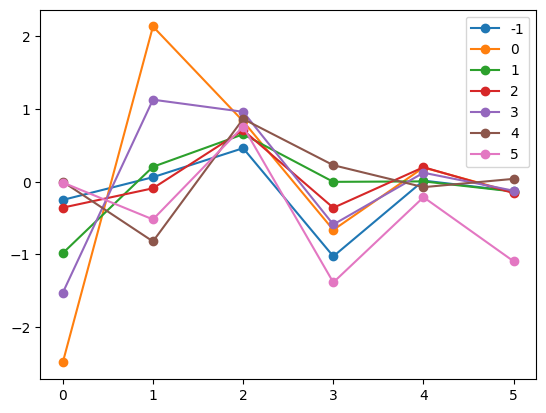

cluster -1
(2027, 6)
mean [ 2.38924519  2.11840158 -0.05278737 -0.20818944  0.18056241 -0.37444499]
std [1.49260396 1.91553043 1.60987207 1.81129276 0.59760836 0.90734987]
cluster 0
(10487, 6)
mean [ 5.26222943e+00  2.22351483e+00 -4.04024030e-01 -5.23123868e-01
  4.57709545e-03 -6.67493087e-03]
std [1.22436989 1.57432682 1.40396631 1.00138849 0.14994367 0.09544441]
cluster 1
(4597, 6)
mean [ 4.82510333  2.27126387 -0.29062432 -0.4033065   0.00761366 -0.01762019]
std [1.46032908 1.44951545 1.34545585 0.94695851 0.26903639 0.17173111]
cluster 2
(15091, 6)
mean [ 5.13637267e+00  2.22192035e+00 -3.94672321e-01 -4.91948844e-01
  2.38552780e-03 -8.54814128e-03]
std [1.32722882 1.53965515 1.37716478 0.95293011 0.16238117 0.1061046 ]
cluster 3
(47282, 6)
mean [ 4.76369443  2.37174823 -0.17361787 -0.46544139  0.01169578 -0.02222833]
std [1.52100445 1.63280826 1.50074197 1.14059671 0.34194559 0.22882088]
cluster 4
(17955, 6)
mean [ 3.69379003  2.41397939  0.32787524 -0.20735171  0.00495684 -0.0

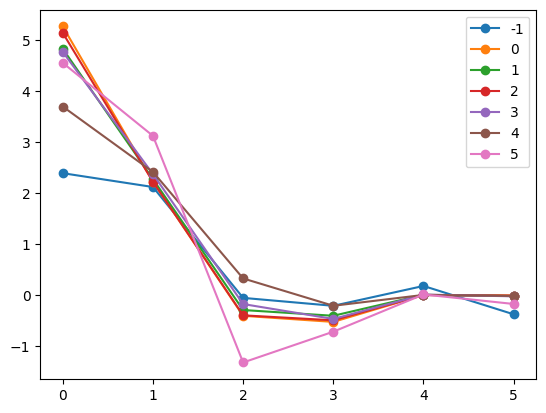

cluster -1
(2027,)
mean 111.10804144055254
std 28.458291683227166
cluster 0
(10487,)
mean 115.49280061027939
std 24.34259153821593
cluster 1
(4597,)
mean 116.17206874048293
std 22.341228631489184
cluster 2
(15091,)
mean 116.08813199920482
std 23.66336254534757
cluster 3
(47282,)
mean 117.03859819804576
std 23.85537200048126
cluster 4
(17955,)
mean 114.45190754664439
std 21.134404625602077
cluster 5
(2561,)
mean 141.05310425614994
std 21.210615042490765


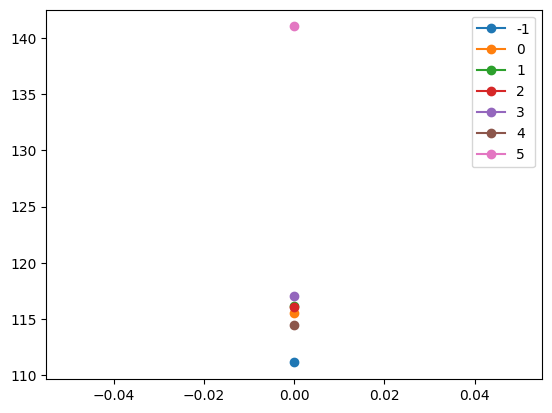

In [71]:

for feature in ['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff','time_core0_iso']:
    for j in data_list:
        a = np.array(clusters_imgep[j][feature])
        print('cluster',j)
        print(a.shape)
        print('mean',a.mean(axis=0))
        print('std',a.std(axis=0))
        plt.plot(a.mean(axis=0),'-o',label=j)
        plt.legend()
    plt.show()


In [ ]:
np.array(clusters_imgep[0]['bus_bandwidth_core_0_diff']).shape

## Attempt UMAP on time seperated raw data!!!

In [72]:
import pandas as pd

j =4
dic_cluster_2_corr = {}

feature_list = ['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff','time_core0_diff']
for cluster in (range(6)):
    list_df = []
    for time in range(6):
        df = pd.DataFrame([])
        for feature in feature_list:
            if feature =='time_core0_diff':
                 df[feature] = np.array(clusters_imgep[cluster]['time_core0_core1']) - np.array(clusters_imgep[cluster]['time_core0_iso'])
            else:
                df[feature] = np.array(clusters_imgep[cluster][feature])[:,time]
        list_df.append(df.corr())
    dic_cluster_2_corr[cluster] = list_df
#np.array(clusters_imgep[hdb.labels_[j]]['bus_bandwidth_core_0_diff']).shape

In [73]:
dic_cluster_2_corr.keys()

dict_keys([0, 1, 2, 3, 4, 5])

In [74]:
dic_cluster_2_corr[1][4].values.round(2)

array([[1.  , 0.68, 0.16, 0.25],
       [0.68, 1.  , 0.08, 0.3 ],
       [0.16, 0.08, 1.  , 0.02],
       [0.25, 0.3 , 0.02, 1.  ]])

In [75]:
feature_list

['bus_bandwidth_core_0_diff',
 'ddr_bandwidth_core_0_diff',
 'cache_misses_l2_diff',
 'time_core0_diff']

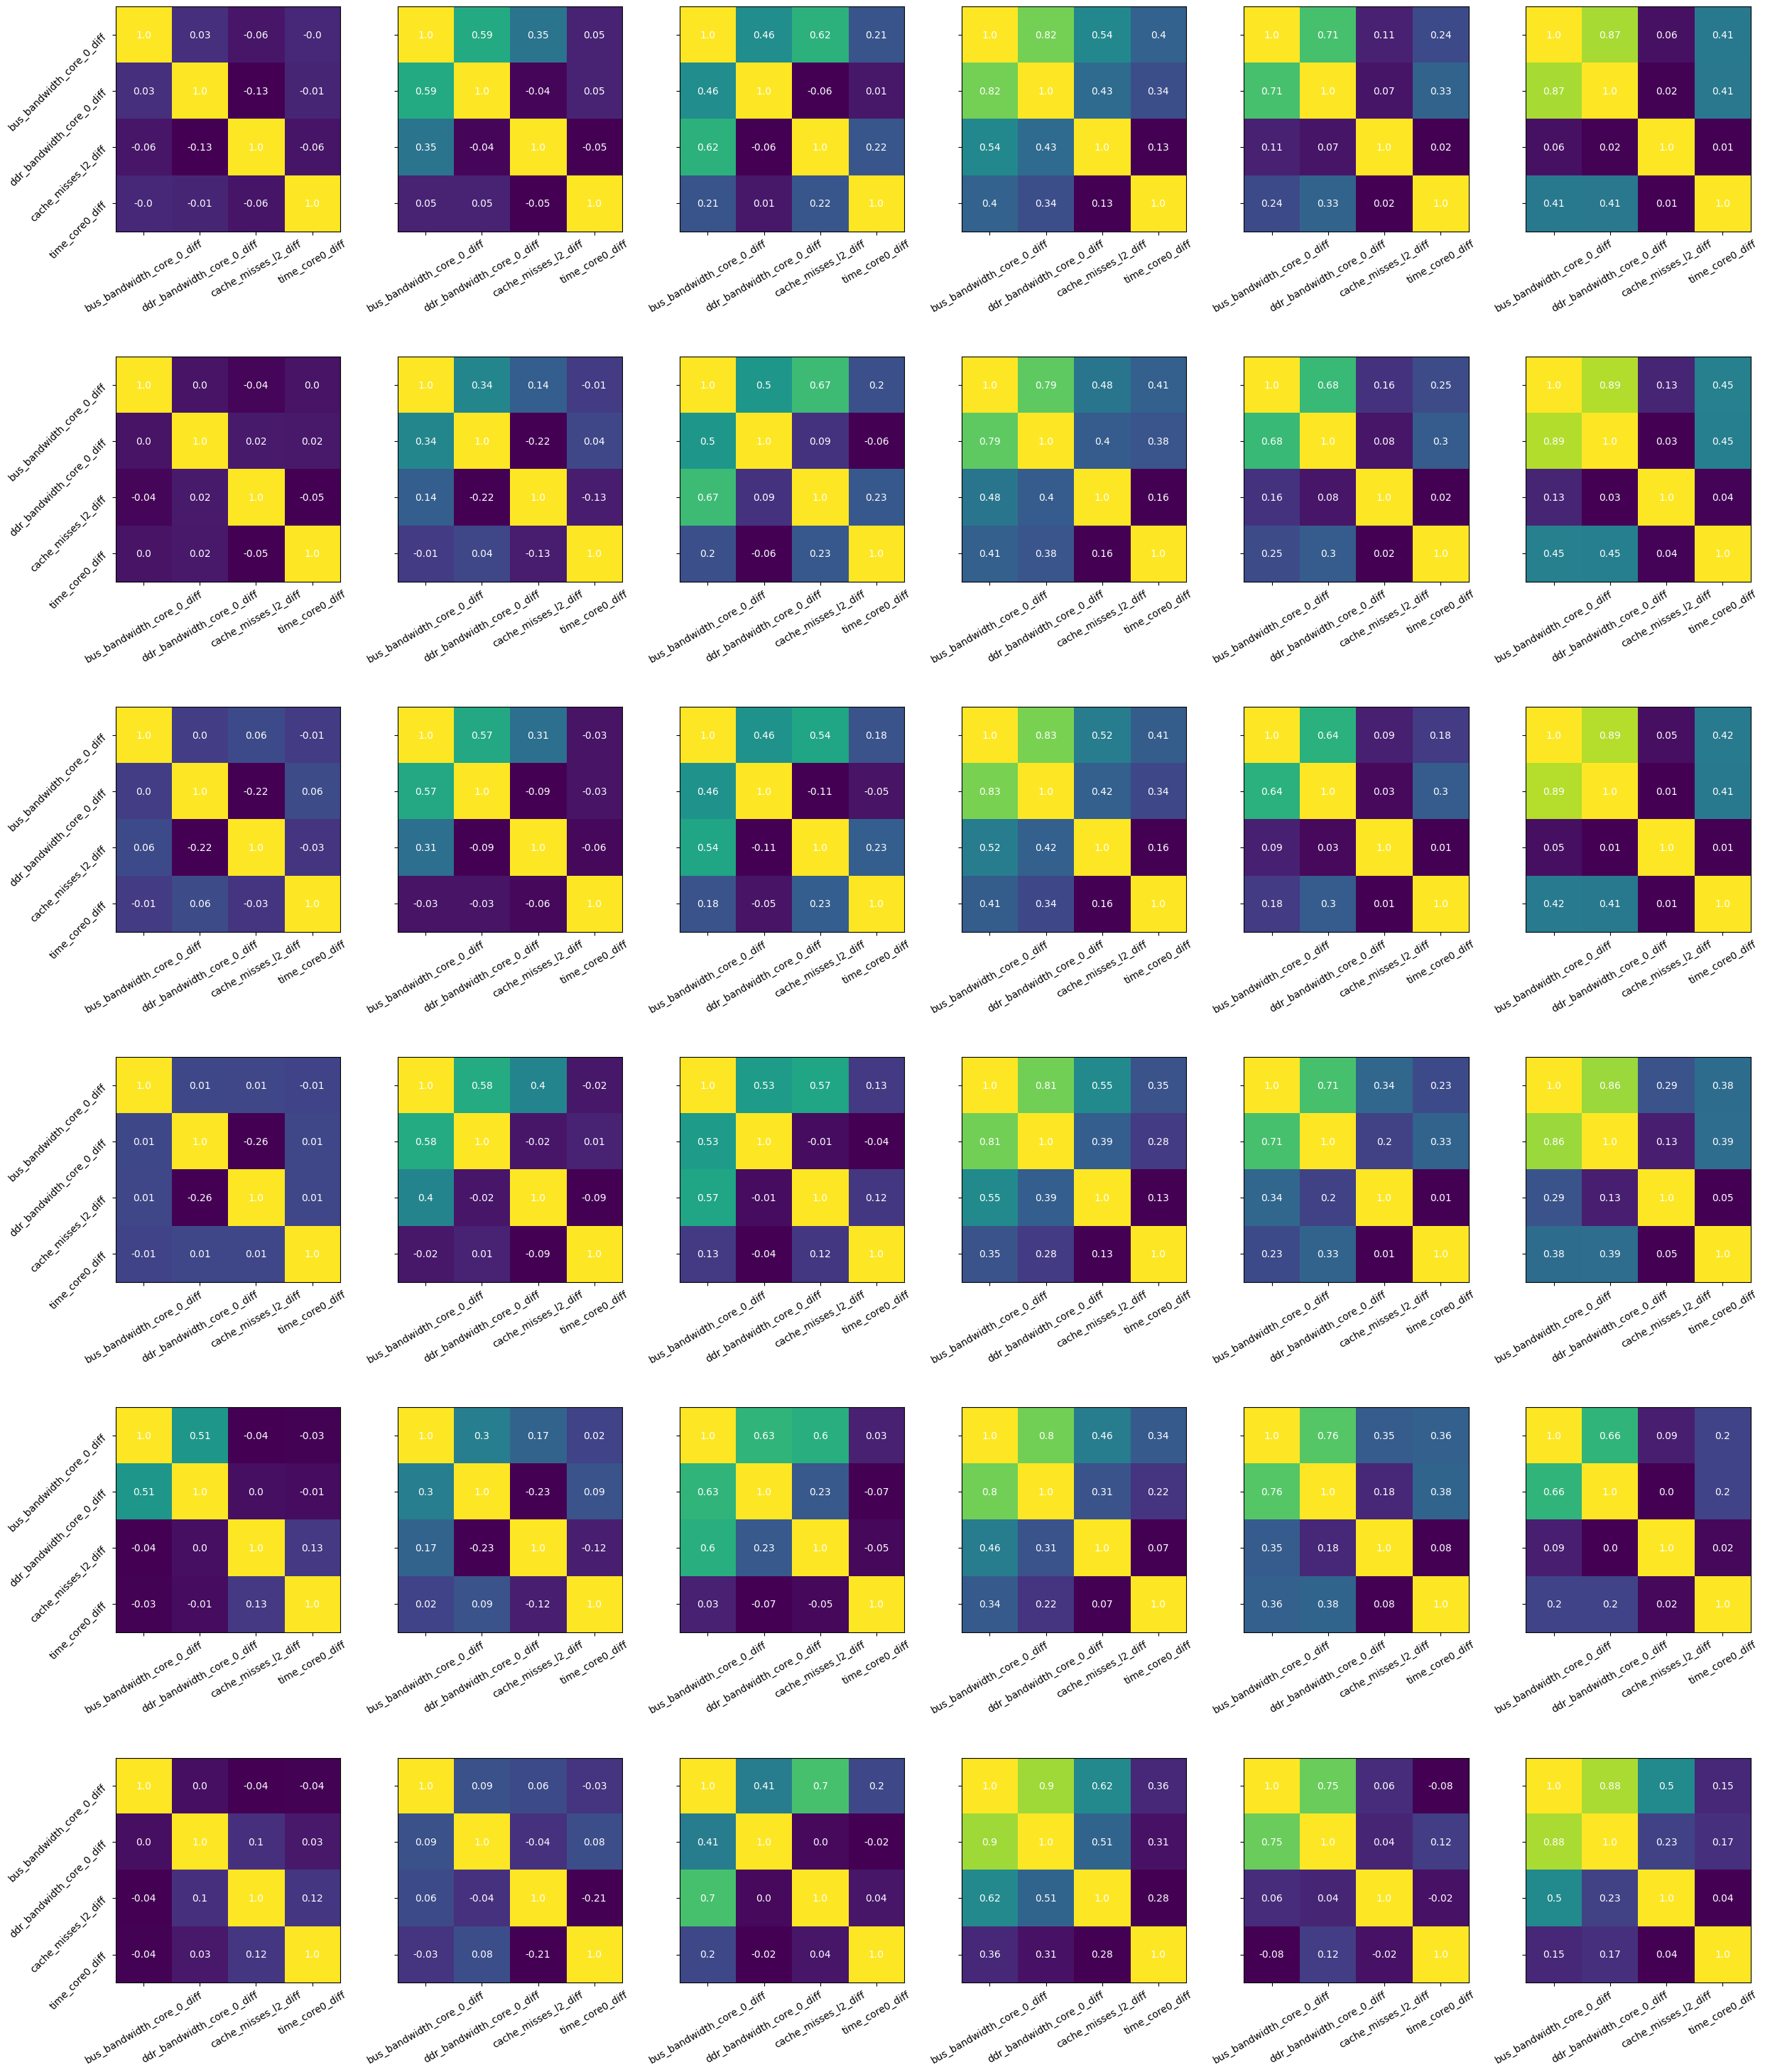

In [76]:
fig, axs = plt.subplots(6, 6, figsize=(25, 30),sharey=True)#,sharex=False)
for time in range(6):
    for clust in range(6):
        # Show all ticks and label them with the respective list entries
        axs[clust,time].imshow(dic_cluster_2_corr[clust][time])
        axs[clust,time].set_xticks(range(len(feature_list)), labels=feature_list,rotation=30)
        axs[clust,time].set_yticks(range(len(feature_list)), labels=feature_list,rotation=45)
        
        # Loop over data dimensions and create text annotations.
        for i in range(len(feature_list)):
            for j in range(len(feature_list)):
                text = axs[clust,time].text(j, i, dic_cluster_2_corr[clust][time].values.round(2)[i, j],ha="center", va="center", color="w")
fig.tight_layout()
plt.show()

In [77]:
content_imgep['memory_observation'].keys()

dict_keys(['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff', 'bus_bandwidth_core_0_iso', 'bus_bandwidth_core_0_core1', 'ddr_bandwidth_core_0_iso', 'ddr_bandwidth_core_0_core1', 'time_core0_iso', 'time_core0_core1'])

In [ ]:
allongement_mean = {}
list_features = ['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff','time_core0_diff']
for feature in list_features:
    allongement_mean[feature] = []
    for j in np.unique(hdb.labels_):
        if feature =='time_core0_diff':
            allongement = np.array(clusters_imgep[j]['time_core0_core1']) - np.array(clusters_imgep[j]['time_core0_iso'])
        else:
            allongement = np.array(clusters_imgep[j][feature])
        #break
        if feature!='time_core0_diff':
            mean_allongement = np.mean(allongement,axis=0)
        else:
            mean_allongement = np.mean(allongement)# a revoir, la matrice est trop grande et on perd de l'information
        allongement_mean[feature].append(mean_allongement)

In [ ]:
plt.figure()
for feature in ['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff','time_core0_diff']:
    for j in range(1,6):
        plt.plot(allongement_mean[feature][j],label=j)
        plt.legend()
        plt.title(feature)
    plt.show()

In [ ]:
for feature in list_features:
    plt.figure()
    plt.bar(np.unique(hdb.labels_),allongement_mean[feature])
    plt.title('mean value '+feature)
    plt.xlabel('clusters')


### Some clusters seem too appear
### Observe correlations matrix for each group
#### try to observe correlation between the attacker metrics and the timing impact ? 

## Attempt to identify clusters with Kmeans on untouched simulator data
--> sklearn website to
"Silhouette analysis can be used to study the separation distance between the resulting clusters. The silhouette plot displays a measure of how close each point in one cluster is to points in the neighboring clusters and thus provides a way to assess parameters like number of clusters visually. This measure has a range of [-1, 1].

Silhouette coefficients (as these values are referred to as) near +1 indicate that the sample is far away from the neighboring clusters. A value of 0 indicates that the sample is on or very close to the decision boundary between two neighboring clusters and negative values indicate that those samples might have been assigned to the wrong cluster."

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
for n_clusters in range(2,6):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit(data)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(data, labels)
    print(
    "For n_clusters =",
    n_clusters,
    "The average silhouette_score is :",
    silhouette_avg,
    )

### --> the values indicate pool clusters as they are far from 1.

# essayer critere elbow pour montrer qu'on ne tire pas grand chose de clusters
# Visualiser clusters